In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import json
from pyproj import Transformer

from pathlib import Path
import rasterio
import matplotlib.pyplot as plt

import pygeohash as pgh
from pygeohash.viz import plot_geohash

from dataset.dataset_meta_concat import SegmentationDatasetMetaConcat

In [11]:
data_path = Path("C:/Users/Administrator/PythonProjects/landcover_classification/ML_datasets/FLAIR1/flair_1_toy_dataset")
json_path = Path("C:/Users/Administrator/PythonProjects/landcover_classification/ML_datasets/FLAIR1/flair_1_metadata_aerial")

images_dir = data_path / "flair_1_toy_aerial_train"
labels_dir = data_path / "flair_1_toy_labels_train"

images = [p for p in images_dir.rglob("*.tif")]
labels = [p for p in labels_dir.rglob("*.tif")]
jsons = [p for p in json_path.rglob("*.json")]

print(len(images))
print(len(labels))
print(len(jsons))

200
200
1


#### Transform JSON, add spatial and temporal hashes

In [30]:
json_path = [p for p in jsons][0]

with open(json_path) as f:
    metadata = json.load(f)
# metadata

In [36]:
def add_lon_lat(metadata: dict) -> dict:
    new_metadata = {}
    transformer = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)

    for key in metadata:
        item = metadata[key]
        x = item["patch_centroid_x"]
        y = item["patch_centroid_y"]
        lon, lat = transformer.transform(x, y)
        item["lon"] = lon
        item["lat"] = lat

        new_metadata[key] = item
    
    return new_metadata

    # # Optionally save back
    # with open("metadata_wgs84.json", "w") as f:
    #     json.dump(data, f, indent=2)

In [39]:
new_metadata = add_lon_lat(metadata)

In [49]:
def create_binary_geohash(
    latitude: float,
    longitude: float,
    precision: int = 12
    ):
    
    geohash = pgh.encode(latitude=latitude, longitude=longitude, precision=precision)
    
    # Convert back to the underlying binary string manually
    # Base32 char -> 5 bits based on geohash alphabet
    alphabet = "0123456789bcdefghjkmnpqrstuvwxyz"
    bitstr = "".join(f"{alphabet.index(c):05b}" for c in geohash)

    # Use that bitstr as a binary feature vector
    binary_gh = [int(b) for b in bitstr]
    
    return binary_gh, geohash

In [50]:
lat = new_metadata["IMG_000001"]["lat"]
lon = new_metadata["IMG_000001"]["lon"]
binary_gh, geohash = create_binary_geohash(latitude=lat, longitude=lon, precision=7)
print(binary_gh)
print(len(binary_gh))

[1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1]
35


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Geohash: spuvtq3'}, xlabel='Longitude', ylabel='Latitude'>)

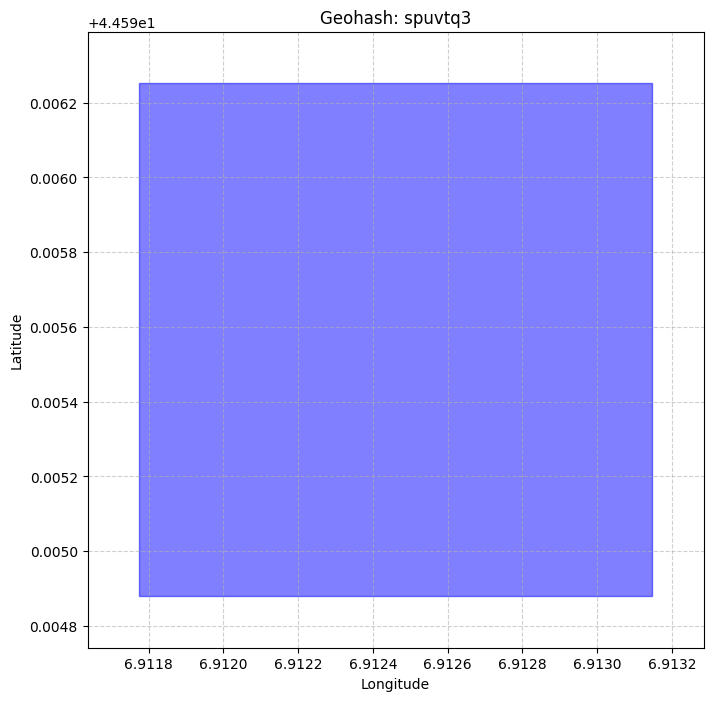

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

# Example geohash
geohash = "u09tunqu"  # Replace with your geohash
lat, lon = pgh.decode(geohash)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    {"geohash": [geohash]},
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"  # WGS84
)

# Convert to Web Mercator for contextily
gdf = gdf.to_crs(epsg=3857)

# Plot
ax = gdf.plot(figsize=(8, 8), color="red", markersize=50)
ctx.add_basemap(ax, source=ctx.providers.Stamen.Terrain)
ax.set_axis_off()
plt.show()

#### Test with Dataset

In [121]:
dataset = SegmentationDatasetMetaConcat(
    images_dir = data_path / "flair_1_toy_aerial_train",
    masks_dir = data_path / "flair_1_toy_labels_train_remap",
    meta_json_dir= json_path,
    augment = None,
    transform = None
)

In [127]:
dict = dataset.__getitem__(1)
print(dict["image_stem"])
print(dict["image"].shape)
print(dict["mask"].shape)

IMG_001119
torch.Size([5, 512, 512])
torch.Size([512, 512])
